In [ ]:
###  most frequent filling --- by mode -- value which has high frequency

## when too much data missing -- create a new column of missing

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

### frequency value imputation

In [3]:
Data_1 = pd.read_csv('categorical_missing_data.csv')
Data_1.head()

,age,gender,smoking_status,blood_group,exercise_level,diet_type,region
0,47,Male,Former Smoker,A+,Moderate,Vegetarian,Urban
1,68,Female,Non-Smoker,NaN,Low,Non-Vegetarian,Suburban
2,44,Male,Former Smoker,B+,Low,Non-Vegetarian,Urban
3,52,Male,Former Smoker,O-,High,Non-Vegetarian,Urban
4,57,Male,Non-Smoker,A-,Moderate,Non-Vegetarian,Suburban


<Axes: xlabel='smoking_status'>

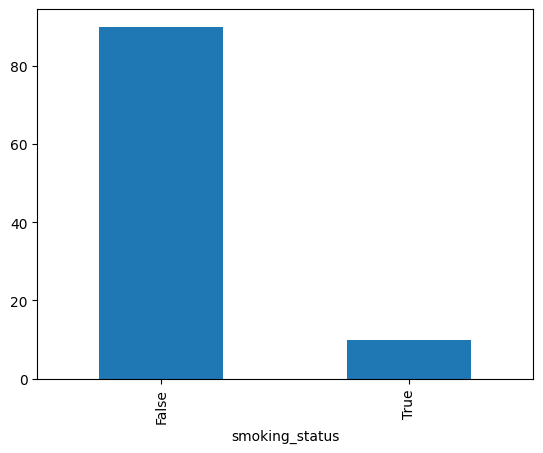

In [34]:
Data_1['smoking_status'].isnull().value_counts().plot.bar()

In [5]:
Data_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             100 non-null    int64
 1   gender          92 non-null     str  
 2   smoking_status  90 non-null     str  
 3   blood_group     87 non-null     str  
 4   exercise_level  92 non-null     str  
 5   diet_type       90 non-null     str  
 6   region          87 non-null     str  
dtypes: int64(1), str(6)
memory usage: 5.6 KB


<Axes: xlabel='smoking_status'>

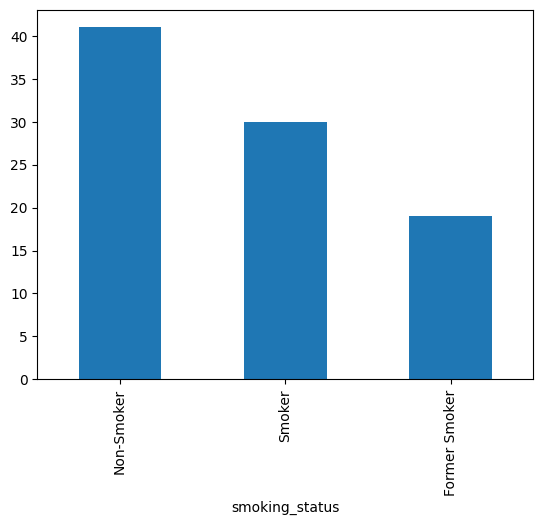

In [6]:
Data_1['smoking_status'].value_counts().sort_values(ascending=False).plot.bar()

<Axes: xlabel='blood_group'>

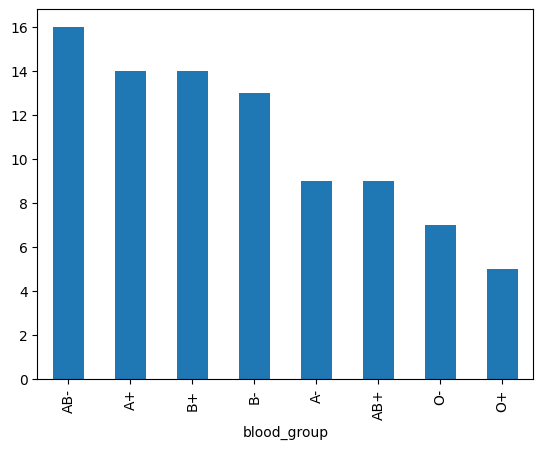

In [7]:
Data_1['blood_group'].value_counts().sort_values(ascending=False).plot.bar()

<Axes: xlabel='exercise_level'>

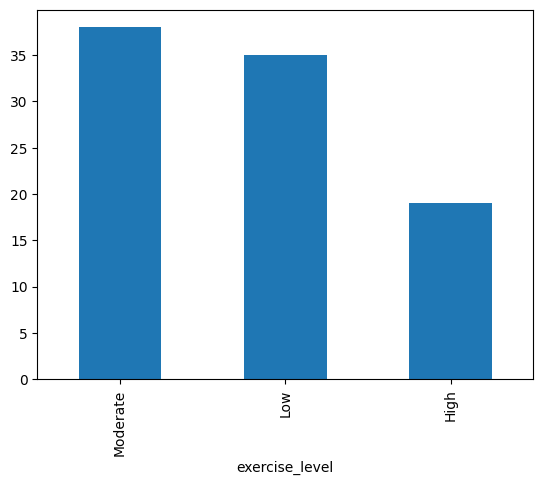

In [8]:
Data_1['exercise_level'].value_counts().sort_values(ascending=False).plot.bar()

In [16]:
Data_1.isnull().mean()*100

age                   0.0
gender                8.0
smoking_status       10.0
blood_group          13.0
exercise_level        8.0
diet_type            10.0
region               13.0
diet_type_imputed     0.0
dtype: float64

<Axes: xlabel='blood_group'>

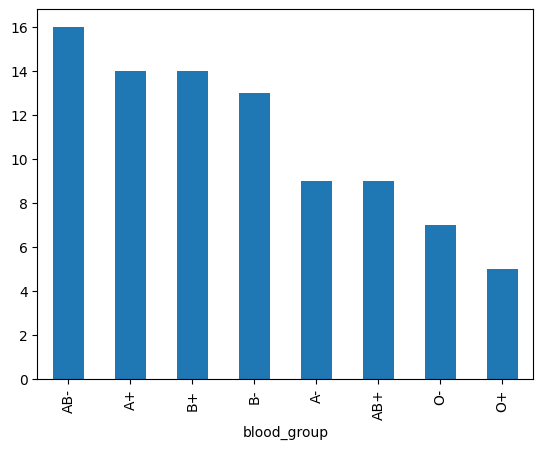

In [17]:
Data_1['blood_group'].value_counts().sort_values(ascending=False).plot.bar()

In [18]:
Data_1['diet_type'].mode()

0    Non-Vegetarian
Name: diet_type, dtype: str

<Axes: xlabel='diet_type'>

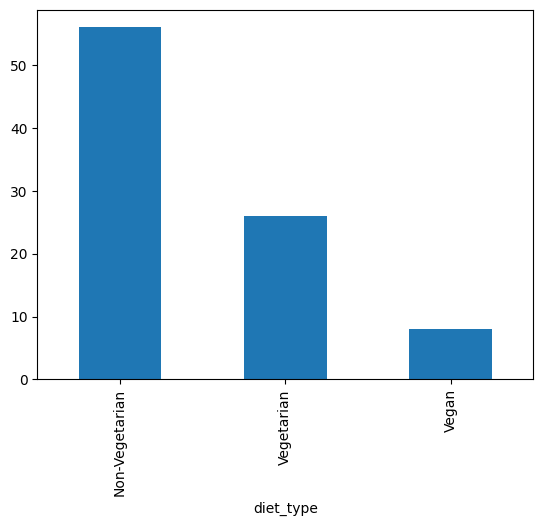

In [9]:
Data_1['diet_type'].value_counts().sort_values(ascending=False).plot.bar()

<Axes: xlabel='region'>

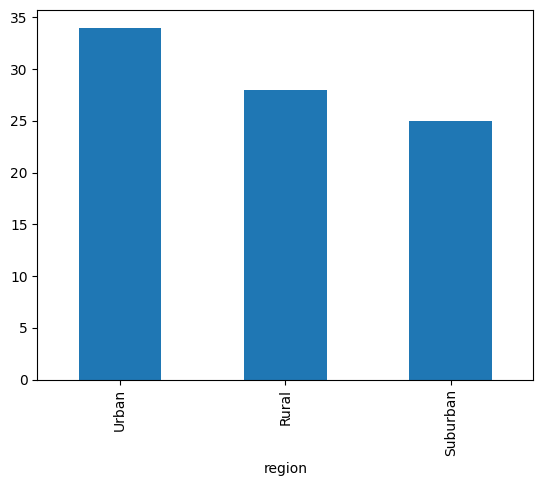

In [10]:
Data_1['region'].value_counts().sort_values(ascending=False).plot.bar()

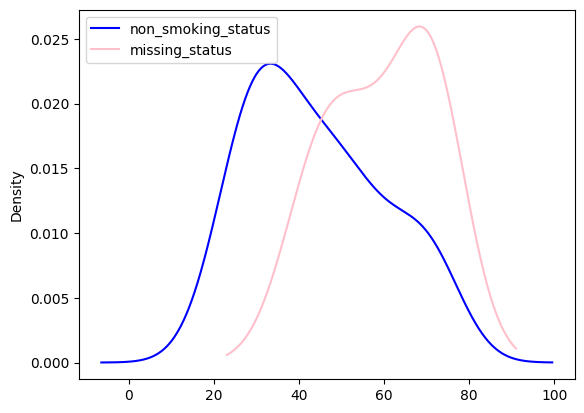

In [19]:
fig = plt.figure()
ax = fig.add_subplot(111)

Data_1[Data_1['smoking_status']=='Non-Smoker']['age'].plot(kind='kde', ax=ax, color='blue')
Data_1[Data_1['smoking_status'].isnull()]['age'].plot(kind='kde', ax=ax, color='pink')

lines, labels = ax.get_legend_handles_labels()
labels =['non_smoking_status', 'missing_status']
ax.legend(lines, labels, loc='best')

In [4]:
Data_1['diet_type'].unique()

<StringArray>
['Vegetarian', 'Non-Vegetarian', 'Vegan', nan]
Length: 4, dtype: str

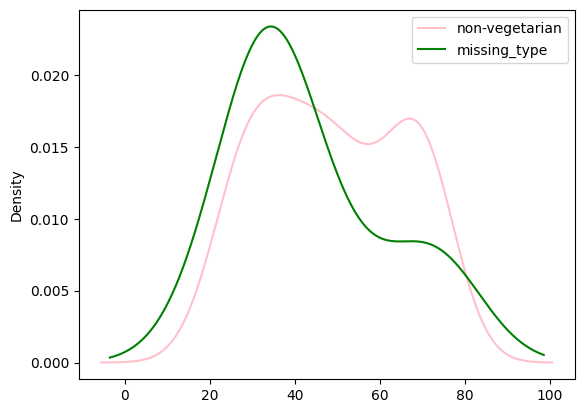

In [20]:
fig = plt.figure()
ax = fig.add_subplot(111)

Data_1[Data_1['diet_type'] == 'Non-Vegetarian']['age'].plot(kind = 'kde', ax=ax, color = 'pink')
Data_1[Data_1['diet_type'].isnull()]['age'].plot(kind = 'kde', ax=ax, color = 'green')

lines, labels = ax.get_legend_handles_labels()
labels =['non-vegetarian', 'missing_type']
ax.legend(lines, labels, loc='best')

In [24]:
temp = Data_1[Data_1['diet_type'] == 'Non-Vegetarian']['age']

In [18]:
Data_1.columns

Index(['age', 'gender', 'smoking_status', 'blood_group', 'exercise_level',
       'diet_type', 'region', 'smoking_status_2'],
      dtype='str')

In [22]:
Data_1['smoking_status_2'] = Data_1['smoking_status'].fillna('Non-Smoker')
Data_1['smoking_status_2']

0     Former Smoker
1        Non-Smoker
2     Former Smoker
3     Former Smoker
4        Non-Smoker
          ...      
95           Smoker
96       Non-Smoker
97       Non-Smoker
98           Smoker
99           Smoker
Name: smoking_status_2, Length: 100, dtype: str

<Axes: xlabel='smoking_status_2'>

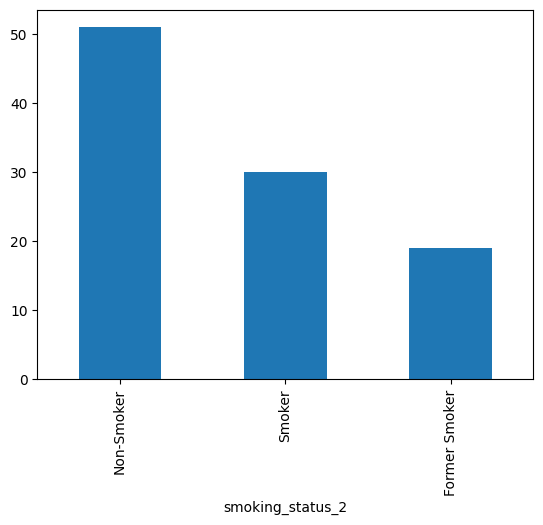

In [23]:
Data_1['smoking_status_2'].value_counts().plot.bar()

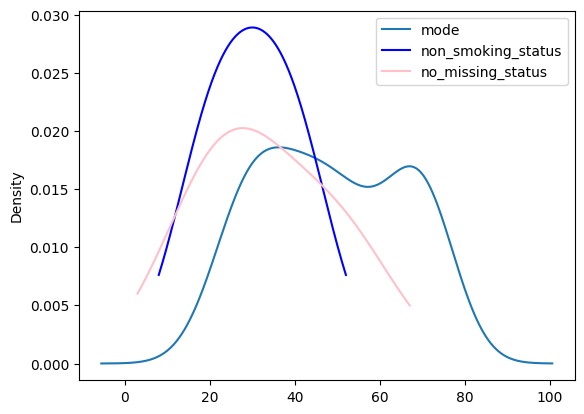

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111)


temp.plot(kind='kde', ax=ax)
Data_1['smoking_status'].value_counts().plot(kind='kde', ax=ax, color='blue')
Data_1['smoking_status_2'].value_counts().plot(kind='kde', ax=ax, color='pink')

lines, labels = ax.get_legend_handles_labels()
labels =['mode', 'non_smoking_status', 'no_missing_status']
ax.legend(lines, labels, loc='best')

In [14]:
Data_1['diet_type_imputed'] = Data_1['diet_type'].fillna('Non-Vegetarian')
Data_1['diet_type_imputed']

0         Vegetarian
1     Non-Vegetarian
2     Non-Vegetarian
3     Non-Vegetarian
4     Non-Vegetarian
           ...      
95             Vegan
96    Non-Vegetarian
97    Non-Vegetarian
98    Non-Vegetarian
99    Non-Vegetarian
Name: diet_type_imputed, Length: 100, dtype: str

<Axes: xlabel='diet_type_imputed'>

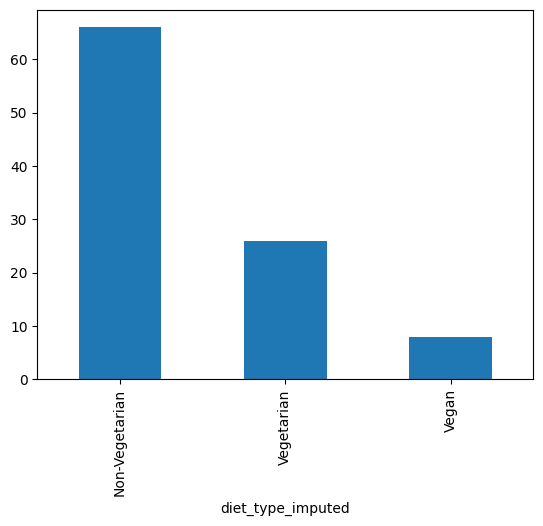

In [21]:
Data_1['diet_type_imputed'].value_counts().plot(kind = 'bar')

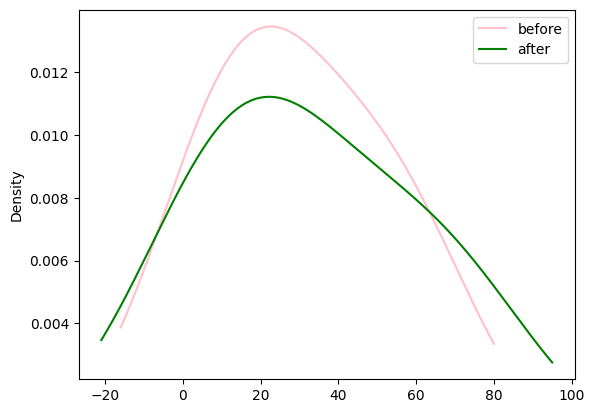

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)

Data_1['diet_type'].value_counts().plot(kind = 'kde', ax=ax, color = 'pink')
Data_1['diet_type_imputed'].value_counts().plot(kind = 'kde', ax=ax, color = 'green')

lines, labels = ax.get_legend_handles_labels()
labels =['before', 'after']
ax.legend(lines, labels, loc='best')

In [ ]:
# random imputation --- applied to both numerical and categ data
# uses the values from the same data
# preserves the variance or distribution